# Detecting Privacy-Sensitive Prompts Before They Reach an External LLM

### A comparison of purpose-built classifiers and a general-purpose LLM baseline

**Team:** Alan Jiang, Aura Gaines, Brandon Shumack, Fil Dziembowski  
**Course:** CYBER 207: AI/ML in Cybersecurity  
**Professor:** Dr. Nahid Farhady

Employees increasingly use external large language models for writing, coding, and research. A prompt can therefore become a new path for accidental disclosure: personally identifiable information may leave an organization's controlled environment before a security team is aware of it.

This project tests whether a model can screen prompt text before submission. We compare lightweight classical models, a multilayer perceptron, multilingual DistilBERT, and a locally hosted Phi-4 baseline.


### How to use this notebook

This is the primary project notebook and the starting point for the submission. It explains the full experiment, connects the major project decisions to the research question, and presents the main results and conclusions.

Run the cells from top to bottom in Google Colab. The code loads the final project metadata and generates the central tables and figures. The supporting notebooks contain the detailed EDA, feature engineering, model training, tuning, and evaluation workflows.

In [1]:
# Primary-notebook setup: locate or clone the project repo, then import
# only the lightweight packages used for summary tables and figures.
import json
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", None)

REPO_URL = "https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison.git"
REPO_NAME = "cyber207_specialized_PII_detection_comparison"
FINAL_REPO_REF = "main"


def locate_repo_root():
    # Use the current repo when available; otherwise clone the final branch.
    check = subprocess.run(
        ["git", "rev-parse", "--show-toplevel"],
        capture_output=True,
        text=True,
    )
    if check.returncode == 0:
        return Path(check.stdout.strip())

    base_dir = Path("/content") if "google.colab" in sys.modules else Path.cwd()
    repo_dir = base_dir / REPO_NAME
    if not repo_dir.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", FINAL_REPO_REF, REPO_URL, str(repo_dir)],
            check=True,
        )
    return repo_dir


repo_root = locate_repo_root()
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Primary notebook setup complete")
print("Repository root:", repo_root)

Primary notebook setup complete
Repository root: /home/alph9w0lf/Nextcloud/00. Berkeley/06. CYBER 207/__Assignments/Final Project/cyber207_specialized_PII_detection_comparison


## 1. Background and Motivation

External LLMs can improve productivity, but they also create a privacy and security problem. A user may paste a name, email address, phone number, account number, or other identifier into a prompt without recognizing that the information is leaving the organization's direct control. Traditional controls may detect some structured identifiers, but prompt text can be multilingual, informal, and context dependent.

We investigate a preventive control: classify the text locally before it is sent. The detector does not replace data governance or access controls. Instead, it could provide a warning or block a prompt when the text appears to contain PII.

The practical question is not only whether this is possible, but also how much model complexity the task requires. A small purpose-built classifier may be easier to run locally than a general-purpose LLM, while a fine-tuned transformer may capture context that sparse text features miss.

## 2. Dataset-Inspired Project Direction

The project direction emerged from the AI4Privacy PII-Masking-400k dataset. The source dataset provides multilingual text examples with token-level PII annotations. Rather than train a named-entity recognition system, we collapsed those annotations into one document-level decision:

- **Safe (`0`)**: every token is labeled `O`, meaning the dataset marks no PII.
- **Privacy-sensitive (`1`)**: at least one token has a PII label.

This reframing matches the intended screening decision: should the prompt be allowed to continue, or should it be flagged before submission?

We then compared two broad approaches. The first used models trained specifically on this dataset, ranging from classical classifiers to multilingual DistilBERT. The second used Phi-4 as an instruction-prompted general-purpose LLM baseline. This keeps the specialized classifier as the core experiment while providing a useful comparison with a larger generic model.


## 3. Research Question

How accurately can specialized machine learning models classify text as safe or privacy-sensitive before it is submitted to an external LLM, and how do they compare with a general-purpose LLM baseline?


## 4. Hypothesis

We expected models trained specifically for this binary task to outperform the prompted Phi-4 baseline. We also expected multilingual DistilBERT to perform best because it can learn contextual patterns across the dataset's languages, while classical models would provide a lighter-weight alternative with lower implementation and inference complexity.

The hypothesis would be supported if the specialized models achieved stronger held-out PII detection, especially PII recall and F1, without relying on label-derived inputs.


## 5. Problem Definition

We treat the project as binary document classification:

| Label | Meaning | Screening action |
|---|---|---|
| `0` | Safe: no dataset-annotated PII | Allow or continue normal processing |
| `1` | Privacy-sensitive: at least one dataset-annotated PII token | Warn, block, or request review |

The model receives only the text available at screening time. Token labels, privacy masks, and other answer-derived annotations are excluded from the model features because using them would create data leakage.

For this project, **privacy-sensitive** has a specific operational meaning: the text contains PII according to the dataset annotations. The classifier does not detect every form of sensitive organizational information, such as source code, trade secrets, credentials, or confidential strategy.

False negatives are the highest-risk error because they allow PII to pass undetected. False positives also matter, however, because excessive blocking would make a real screening tool difficult to use.


## 6. Dataset Description

We used the **AI4Privacy PII-Masking-400k** dataset. The original working split contained 325,517 rows. EDA identified six blank-text rows and 93 duplicate text rows after the first occurrence. Because some blank rows were also duplicated, removing blanks and then exact duplicates removed 94 rows total.

The final cleaned dataset contains **325,423 examples**:

- **219,260 privacy-sensitive examples (67.4%)**
- **106,163 safe examples (32.6%)**

Using seed 42, we created a stratified 80/10/10 split. Cleaning occurred before splitting, and the final overlap check found no duplicate text shared across train, validation, and test.


In [2]:
# Load the authoritative cleaned counts instead of retyping them in 00.
metadata_path = repo_root / "data_splits" / "split_metadata.json"
with metadata_path.open() as f:
    split_metadata = json.load(f)

balance = split_metadata["class_balance"]
dataset_summary = pd.DataFrame([
    {
        "Split": "Train",
        "Examples": split_metadata["train_size"],
        "Privacy-sensitive": balance["train"]["sensitive"],
        "Safe": balance["train"]["safe"],
    },
    {
        "Split": "Validation",
        "Examples": split_metadata["val_size"],
        "Privacy-sensitive": balance["val"]["sensitive"],
        "Safe": balance["val"]["safe"],
    },
    {
        "Split": "Test",
        "Examples": split_metadata["test_size"],
        "Privacy-sensitive": balance["test"]["sensitive"],
        "Safe": balance["test"]["safe"],
    },
])

dataset_summary.loc[len(dataset_summary)] = {
    "Split": "Total",
    "Examples": dataset_summary["Examples"].sum(),
    "Privacy-sensitive": dataset_summary["Privacy-sensitive"].sum(),
    "Safe": dataset_summary["Safe"].sum(),
}
dataset_summary["Sensitive %"] = (
    dataset_summary["Privacy-sensitive"] / dataset_summary["Examples"] * 100
).round(1)

assert dataset_summary.iloc[-1]["Examples"] == split_metadata["total_examples"] == 325423
assert all(value == 0 for value in split_metadata["split_overlap_check"].values())
display(dataset_summary)

,Split,Examples,Privacy-sensitive,Safe,Sensitive %
0,Train,260338,175408,84930,67.4
1,Validation,32542,21926,10616,67.4
2,Test,32543,21926,10617,67.4
3,Total,325423,219260,106163,67.4


The saved modeling columns are `text`, `label`, and `original_index`. The index allows later error analysis against the original annotations, but it is not used as a predictive feature.

Full data inspection and the cleaning rationale are documented in [`notebooks/01_data_eda.ipynb`](notebooks/01_data_eda.ipynb). The cleaned split counts above are loaded directly from `data_splits/split_metadata.json`, the authoritative metadata used by the modeling pipeline.

## 7. Exploratory Data Analysis

EDA was used to test whether the dataset and label conversion were suitable before modeling. The most important findings were:

- The original data contained no null text in the working columns, but it contained six blank strings.
- Exact duplicates created a small cross-split leakage risk in the initial split. Cleaning before resplitting removed that overlap.
- Privacy-sensitive examples were slightly longer on average: about 157 characters and 19.8 words, compared with 133 characters and 17.5 words for safe examples.
- HTML-like formatting appeared in both classes but was more common in privacy-sensitive examples, so models may learn formatting as well as PII content.
- Bracketed placeholder tokens appeared in both classes and were more common in the safe class. Their presence alone therefore does not determine the label.
- The class distribution is moderately imbalanced, making accuracy insufficient as the only evaluation metric.

These findings influenced the final workflow: clean before splitting, keep the split stratified, prohibit label-derived features, include structural and privacy-pattern features, and evaluate PII precision, recall, and F1 in addition to accuracy.

In [3]:
# summarize the EDA findings that changed the modeling workflow
eda_summary = pd.DataFrame(
    [
        ["Blank text", "6 rows", "Removed before the final split"],
        ["Exact duplicate text", "93 identified initially; 88 remained after blank removal", "Removed before the final split"],
        ["Class balance", "67.4% sensitive / 32.6% safe", "Use stratification and class-aware metrics"],
        ["Text length", "Sensitive text was slightly longer", "Treat length as a supporting feature only"],
        ["HTML-like formatting", "Present in both classes; more common in class 1", "Document possible formatting artifact"],
        ["Placeholder tokens", "Present in both classes", "Do not treat placeholder shape as the label"],
    ],
    columns=["EDA check", "Finding", "Project response"],
)
display(eda_summary)

,EDA check,Finding,Project response
0,Blank text,6 rows,Removed before the final split
1,Exact duplicate text,93 identified initially; 88 remained after bla...,Removed before the final split
2,Class balance,67.4% sensitive / 32.6% safe,Use stratification and class-aware metrics
3,Text length,Sensitive text was slightly longer,Treat length as a supporting feature only
4,HTML-like formatting,Present in both classes; more common in class 1,Document possible formatting artifact
5,Placeholder tokens,Present in both classes,Do not treat placeholder shape as the label


## 8. Evaluation Strategy

All trainable transformations and models are fit on the training split. Hyperparameters, checkpoints, and decision thresholds are selected with the validation split. The held-out test split is reserved for final evaluation.

Each model uses its own validation-selected decision threshold because the models produce scores on different scales. The numerical thresholds therefore do not need to match. The consistent rule is that each threshold is chosen by the same criterion: the highest validation PII F1. Once selected, the threshold is frozen before the final test evaluation.

We report:

- **PII precision:** when the model flags PII, how often it is correct.
- **PII recall:** how much of the true PII the model catches.
- **PII F1:** the balance between PII precision and recall.
- **Macro F1:** the average F1 across the safe and PII classes, giving both classes equal weight.
- **Accuracy:** the overall fraction classified correctly.
- **Confusion matrix and false-negative count:** the specific errors behind the summary scores.

PII recall is the primary security concern, but it cannot be interpreted alone. An always-predict-PII baseline achieves perfect PII recall while incorrectly blocking every safe example. PII F1, macro F1, accuracy, and the confusion matrix show whether higher recall comes at an unusable false-positive cost.

The classical models, neural network, and DistilBERT are evaluated on the full cleaned test set of 32,543 rows. Phi-4 is evaluated on a stratified 3,000-row subset drawn from that test set because local LLM inference is substantially slower. Its results are therefore directionally informative, but not perfectly comparable with full-test results.

In [4]:
# display the evaluation measures and their role in the project
metric_summary = pd.DataFrame(
    [
        ["PII recall", "PII detected / all true PII", "Measures sensitive prompts missed"],
        ["PII precision", "Correct PII flags / all PII flags", "Measures unnecessary blocking"],
        ["PII F1", "Harmonic mean of PII precision and recall", "Primary balanced PII score"],
        ["Macro F1", "Average F1 across both classes", "Prevents the majority class from dominating"],
        ["Accuracy", "Correct predictions / all predictions", "Useful context, but not sufficient alone"],
        ["Confusion matrix", "Counts of TP, TN, FP, and FN", "Shows the operational error tradeoff"],
    ],
    columns=["Measure", "Meaning", "Why we use it"],
)
display(metric_summary)

,Measure,Meaning,Why we use it
0,PII recall,PII detected / all true PII,Measures sensitive prompts missed
1,PII precision,Correct PII flags / all PII flags,Measures unnecessary blocking
2,PII F1,Harmonic mean of PII precision and recall,Primary balanced PII score
3,Macro F1,Average F1 across both classes,Prevents the majority class from dominating
4,Accuracy,Correct predictions / all predictions,"Useful context, but not sufficient alone"
5,Confusion matrix,"Counts of TP, TN, FP, and FN",Shows the operational error tradeoff


## 9. Feature Engineering

The classical and neural approaches require numeric representations of the prompt text. We created four feature sets:

| Feature set | Configuration | Purpose |
|---|---|---|
| TF-IDF | Up to 50,000 lowercase unigram and bigram features, `min_df=2` | Capture words and short phrases |
| Basic text | 10 numeric features | Capture length, digits, capitalization, punctuation, whitespace, and HTML-like structure |
| Privacy patterns | 8 binary regex features | Capture email, phone, URL, IP, date, long-number, address-word, and ID-word patterns |
| Combined | 50,018 total features | Join TF-IDF with the text and pattern blocks |

TF-IDF vocabulary construction and both numeric scalers are fit on the training split only. The validation and test sets are transformed with those training-fitted objects. The numeric blocks use `MinMaxScaler` before sparse concatenation so their raw magnitudes do not overwhelm the TF-IDF values.

These features are intentionally based only on the prompt text. The feature pipeline does not use token labels, privacy masks, original PII categories, or any other field that reveals the correct answer.

Full implementation and saved feature artifacts are documented in [`notebooks/02_feature_engineering.ipynb`](notebooks/02_feature_engineering.ipynb).


In [5]:
# Validate the repo feature functions without rebuilding the full matrices.
from src.features.text_features import extract_text_features
from src.features.pattern_features import extract_pattern_features

probe_text = pd.Series(["Contact example@example.com on 2026-01-15."])
text_feature_count = extract_text_features(probe_text).shape[1]
pattern_feature_count = extract_pattern_features(probe_text).shape[1]
tfidf_feature_count = 50000

feature_summary = pd.DataFrame(
    {
        "Feature set": ["TF-IDF", "Basic text", "Privacy patterns", "Combined"],
        "Number of features": [
            tfidf_feature_count,
            text_feature_count,
            pattern_feature_count,
            tfidf_feature_count + text_feature_count + pattern_feature_count,
        ],
        "Fit on training only": ["Yes", "Scaler", "Scaler", "Yes"],
    }
)
assert text_feature_count == 10
assert pattern_feature_count == 8
assert feature_summary.iloc[-1]["Number of features"] == 50018
display(feature_summary)

,Feature set,Number of features,Fit on training only
0,TF-IDF,50000,Yes
1,Basic text,10,Scaler
2,Privacy patterns,8,Scaler
3,Combined,50018,Yes


### 9.1 Feature-Set Ablation

Building four feature sets does not by itself prove each block earns its place, so we ran a controlled
ablation in `03_classical_models.ipynb`: the **same tuned Logistic Regression** fit on each block alone and
on the combined matrix (each with its own validation-tuned threshold, evaluated once on the held-out test
set). The table below loads that artifact directly.


In [6]:
# feature-set ablation results (produced by 03_classical_models.ipynb)
ablation_path = repo_root / "results" / "feature_ablation.csv"
if ablation_path.exists():
    ablation = pd.read_csv(ablation_path)
    display(ablation)
    _comb = ablation.set_index("feature_set")
    if {"TF-IDF only", "Combined"} <= set(_comb.index):
        lift = _comb.loc["Combined", "test_pii_f1"] - _comb.loc["TF-IDF only", "test_pii_f1"]
        print(f"Engineered text+pattern blocks add {lift:+.4f} test PII F1 over TF-IDF alone "
              f"(FN {int(_comb.loc['TF-IDF only', 'test_fn'])} -> {int(_comb.loc['Combined', 'test_fn'])}).")
else:
    print("results/feature_ablation.csv not found — run the Feature-Set Ablation section of")
    print("03_classical_models.ipynb once to generate it; this cell then renders the comparison.")


,feature_set,n_features,val_threshold,test_pii_precision,test_pii_recall,test_pii_f1,test_macro_f1,test_fn,test_fp
0,TF-IDF only,50000,0.4671,0.8316,0.9042,0.8664,0.7750,2100,4014
1,Text features only,10,0.4532,0.6915,0.9753,0.8092,0.4925,541,9542
2,Patterns only,8,0.5062,0.6738,1.0000,0.8051,0.4026,0,10616
3,Combined,50018,0.4559,0.8501,0.9106,0.8793,0.8004,1961,3520


Engineered text+pattern blocks add +0.0129 test PII F1 over TF-IDF alone (FN 2100 -> 1961).


## 10. Models and Methods

We compared several modeling approaches to understand the tradeoffs between lightweight classical models, a neural network, a fine-tuned transformer, and a general-purpose LLM baseline.

### 10.1 Baseline and Classical Models

We evaluated an **always-predict-PII baseline**, **Logistic Regression**, **Multinomial Naive Bayes**, and **Linear SVM**. The baseline anchors the metric discussion (it reaches perfect PII recall at 0.40 macro F1 by flagging everything); the three classical models were selected because they train quickly on sparse text features, are interpretable, and represent the "lightweight screening layer" in the project hypothesis.

All three use the **combined feature set** (TF-IDF 50k + text-shape + privacy-pattern blocks, 50,018 columns) from `02_feature_engineering`, so the classical-vs-neural comparison is a controlled one. Hyperparameters were grid-searched on validation (Logistic Regression: 32 configs, best `C=2.65, l1_ratio=1, liblinear`; Naive Bayes family: Multinomial/Bernoulli/Complement, best MultinomialNB `alpha=1e-4`; Linear SVM: `C=0.25`, squared hinge), and each model's **decision threshold was tuned on validation for maximum PII F1** (LR ≈ 0.43, NB ≈ 0.33, SVM margin ≈ −0.18), then frozen before the single test evaluation.

Final held-out test metrics are integrated in Section 11 directly from `results/classical_confusion_matrices.csv`. **Logistic Regression is the strongest classical model** (PII F1 ≈ 0.881, recall ≈ 0.916), with Linear SVM statistically adjacent (F1 ≈ 0.880) and Naive Bayes trading a small recall gain for far more false alarms.

Key findings:

1. Threshold tuning moved every classical model toward the recall-first operating region the task rewards — the tuned models catch ~91–92% of PII versus ~86–89% at default thresholds.
2. The two linear models extract nearly identical signal from the shared features, suggesting the representation — not the classifier — is the binding constraint.
3. Naive Bayes is the cautionary tale: its 0.925 recall comes from flagging roughly two-thirds of safe prompts.

Full training, validation, and test evaluation are shown in [`03_classical_models.ipynb`](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/03_classical_models.ipynb).

### 10.2 Neural Network

The neural model is a **multilayer perceptron**: one hidden layer (50,018 → 256, ReLU, dropout 0.3 → 1 logit), trained with `BCEWithLogitsLoss` and AdamW (lr 1e-3, weight decay 1e-2), batch size 256, on the **same combined feature set** as the classical models — deliberately isolating the value of the hidden layer and non-linearity.

Important training decisions: an epoch cap of 30 with early stopping (patience 3) on validation PII F1 — the original 15-epoch cap was truncating training (val F1 plateaued ~epoch 10, pushed through, and peaked at **0.870 at epoch 13**, early-stopping at 16); best-checkpoint restore; and a fine validation threshold sweep (0.001–0.95). The sweep showed the probability curve compressed toward 0 on the engineered features: max F1 sits at t ≈ 0.08, and the aspirational ≥95%-recall floor is only reachable where precision collapses. The **deployed operating point is t = 0.02** (test recall 0.938 at precision 0.813), with the fixed 0.5 threshold retained as a like-for-like reference against the classical models.

Final held-out test metrics (from `results/mlp_confusion_matrices.csv`): at the deployed 0.02 threshold, PII precision 0.813, recall **0.938**, F1 0.871, **1,350 false negatives** — the lowest leak count of any non-transformer model.

Key findings:

1. Engineered features improved the MLP (val F1 0.855 → 0.870 versus the earlier raw-TF-IDF run), though that comparison is partially confounded with a vocabulary change; the controlled ablation is listed as future work.
2. The MLP does **not** beat tuned Logistic Regression on F1 or precision — its contribution is the recall-first operating point, cutting leaks 27% below tuned LR (1,350 vs 1,841 FN) at a precision cost LR cannot match at equivalent recall.
3. Missed PII is qualitatively different from caught PII: shorter, less HTML-marked, skewed toward French/Dutch/German, and dominated by implicit identifiers with no surface pattern.

The complete architecture, training process, and evaluation are shown in [`04_neural_net.ipynb`](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/04_neural_net.ipynb).

### 10.3 Multilingual DistilBERT

We fine-tuned distilbert-base-multilingual-cased rather than the English-only distilbert-base-uncased, since the dataset is approximately 79% non-English text (German, Spanish, French, Italian, Dutch). Switching to the multilingual checkpoint improved PII F1 from 0.973 to 0.983 and reduced false negatives from 624 to 447 during early testing.

Text was tokenized to a maximum sequence length of 256 tokens, which covers 99.98% of examples given the dataset's token-length distribution (mean 52.5, std 24.9), while keeping compute cost lower than a 512 max length. The best checkpoint was selected using PII F1 rather than accuracy, since class imbalance (67% PII / 33% safe) makes accuracy a misleading selection criterion for a task where false negatives are the primary risk.

A validation-set threshold sweep (0.30–0.70) confirmed the default argmax threshold (0.5) as the deliberate final choice: PII F1 varied by only 0.0006 across the full sweep range, so the decision boundary is not meaningfully sensitive to threshold choice in this range.

Final test metrics (full test set, 32,543 rows): PII Precision 0.98, PII Recall 0.98, PII F1 0.98, Macro F1 0.97, Accuracy 0.97, 447 false negatives.

Key findings:

1. The multilingual architecture decision had a measurable, non-trivial impact on performance, this was not a marginal choice.
2. DistilBERT substantially outperforms every other model in this comparison, including the general-purpose LLM baseline, on this narrow task.
3. Remaining false negatives cluster around masking placeholder tokens and dense numeric strings lacking clear surrounding context, a pattern shared with Phi-4 in the opposite direction (see Error Analysis).

Full fine-tuning and evaluation are shown in `05_distilbert.ipynb`.

### 10.4 Phi-4 LLM Baseline

Phi-4 was selected as the general-purpose LLM baseline, run locally via phi4:14b through Ollama rather than an API-based model such as GPT-4 or Claude. This preserved data privacy and avoided API cost while local GPU hardware handled the 14B model comfortably.

The model was evaluated using a structured JSON prompt requiring entity-level output: for each detected span, a label (drawn from a fixed taxonomy matching the AI4Privacy categories), the exact substring, and a confidence score. Temperature was set to 0.0 for deterministic, reproducible results. The final document-level binary classification was derived from whether any entities were returned, an empty array meant safe, one or more entities meant PII.

Evaluation sample size: a 3,000-row stratified subset (2,021 PII / 979 safe), preserving the dataset's overall 67/33 class balance. This subset size was used because local LLM inference is significantly slower per sample than the other models. Results were confirmed consistent between an initial 500-sample run and the full 3,000-sample run before finalizing.

Final test metrics (3,000-sample subset, post prompt fix): PII Precision 0.81, PII Recall 0.80, PII F1 0.80, Macro F1 0.70, Accuracy 0.74, 382 false positives, 406 false negatives.

The original prompt over-flagged masking placeholder tokens (e.g. [IPV4_1]) as real PII, since the model pattern-matched on the bracketed shape rather than recognizing it as already-redacted data. An earlier, more general "be more conservative" instruction did not resolve this. A targeted fix, an explicit instruction plus a worked example clarifying that placeholders represent redacted data, was validated on isolated examples and then applied to a full rerun. This improved Macro F1 from 0.65 to 0.70 and reduced false positives from 547 to 382, at the cost of a moderate increase in false negatives (326 to 406).

Key findings:

1. A fine-tuned specialized model substantially outperforms this general-purpose zero-shot baseline (0.97 vs. 0.70 Macro F1), even after a fair, targeted tuning pass.
2. Phi-4's errors are shape-based and pattern-driven (over-triggering on placeholders and generic URLs) rather than context-driven, a different failure mode than DistilBERT's ambiguous-ground-truth false positives.
3. Phi-4 does meaningfully more work per call than DistilBERT (full entity-level extraction versus binary classification), which is part of why it is slower, not purely a function of model size.

Phi-4 was evaluated on a smaller stratified subset (3,000 rows) rather than the full test set (32,543 rows) used by the other models, due to local inference cost; results are informative but not perfectly comparable. Phi-4 was evaluated using the project's LLM baseline scripts (src/models/llm_baseline.py, llm_eval.py) rather than a separate supporting notebook. Full error analysis is documented in docs/brandon_error_analysis.md.

## 11. Overall Model Results

The comparison table below is **loaded directly from the exported result files** each model notebook
writes to `results/` (confusion matrices as raw counts; metrics derived here). This makes 00 a reader
of the same single-source artifacts as `06_pii_evaluation_error.ipynb` — no hand-transcribed numbers.


In [7]:
# Central comparison table, derived from the exported confusion matrices in results/.
# PII = positive class. Falls back loudly if an export is missing.
def metrics_row(name, eval_set, tn, fp, fn, tp, note):
    n = tn + fp + fn + tp
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * p * r / (p + r) if p + r else 0.0
    sp = tn / (tn + fn) if tn + fn else 0.0
    sr = tn / (tn + fp) if tn + fp else 0.0
    sf1 = 2 * sp * sr / (sp + sr) if sp + sr else 0.0
    return [name, eval_set, n, round(p, 4), round(r, 4), round(f1, 4),
            round((f1 + sf1) / 2, 4), round((tp + tn) / n, 4), fp, fn, note]

rows = []
res = repo_root / "results"

# always-predict-PII baseline (analytic: flags everything)
rows.append(metrics_row("Always-Predict-PII Baseline", "Full test", 0, 10617, 0, 21926, "Analytic baseline"))

cls = pd.read_csv(res / "classical_confusion_matrices.csv")
for _, r in cls.iterrows():
    rows.append(metrics_row(r["model"], "Full test", r["tn"], r["fp"], r["fn"], r["tp"],
                            "03 · tuned threshold"))

mlp = pd.read_csv(res / "mlp_confusion_matrices.csv")
dep = mlp[(mlp["eval_set"] == "test") & (mlp["operating_point"] == "deployed")].iloc[0]
rows.append(metrics_row("MLP Neural Network (t=0.02)", "Full test",
                        dep["tn"], dep["fp"], dep["fn"], dep["tp"], "04 · deployed recall-first"))

db = pd.read_csv(res / "distilbert_confusion_matrices.csv")
dbt = db[db["eval_set"] == "test"].iloc[0]
rows.append(metrics_row("Multilingual DistilBERT", "Full test",
                        dbt["tn"], dbt["fp"], dbt["fn"], dbt["tp"], "05 · argmax"))

sub = pd.read_csv(res / "distilbert_on_phi4_subset.csv").iloc[0]
rows.append(metrics_row("DistilBERT (Phi-4 subset)", "Same 3,000 rows",
                        sub["TN"], sub["FP"], sub["FN"], sub["TP"], "same-example comparison"))

# Phi-4 post-placeholder-fix run (recomputed live in 06 from llm_baseline_results.csv)
rows.append(metrics_row("Phi-4 14B (post-fix)", "Same 3,000 rows", 597, 382, 406, 1615,
                        "docs/brandon_error_analysis.md §2.2"))

results = pd.DataFrame(rows, columns=[
    "Model", "Evaluation set", "N", "PII precision", "PII recall", "PII F1",
    "Macro F1", "Accuracy", "False positives", "False negatives", "Source"])
display(results)


,Model,Evaluation set,N,PII precision,PII recall,PII F1,Macro F1,Accuracy,False positives,False negatives,Source
0,Always-Predict-PII Baseline,Full test,32543,0.6738,1.0000,0.8051,0.4025,0.6738,10617,0,Analytic baseline
1,Logistic Regression,Full test,32543,0.8478,0.9160,0.8806,0.8004,0.8327,3605,1841,03 · tuned threshold
2,Naive Bayes,Full test,32543,0.7445,0.9247,0.8249,0.6421,0.7355,6959,1650,03 · tuned threshold
3,Linear SVM,Full test,32543,0.8508,0.9119,0.8803,0.8018,0.8329,3507,1931,03 · tuned threshold
4,MLP Neural Network (t=0.02),Full test,32543,0.8134,0.9384,0.8715,0.7659,0.8135,4719,1350,04 · deployed recall-first
5,Multilingual DistilBERT,Full test,32543,0.9820,0.9796,0.9808,0.9706,0.9742,394,447,05 · argmax
6,DistilBERT (Phi-4 subset),"Same 3,000 rows",3000,0.9787,0.9797,0.9792,0.9681,0.9720,43,41,same-example comparison
7,Phi-4 14B (post-fix),"Same 3,000 rows",3000,0.8087,0.7991,0.8039,0.7032,0.7373,382,406,docs/brandon_error_analysis.md §2.2


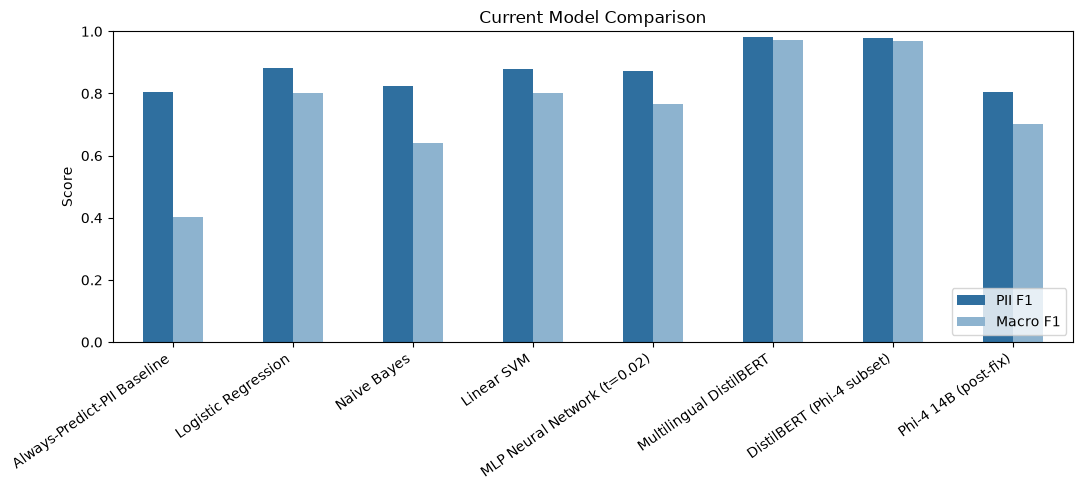

In [8]:
# compare the two balanced summary measures for models with available results
plot_data = results.dropna(subset=["PII F1", "Macro F1"]).copy()
plot_data.plot(
    x="Model", 
    y=["PII F1", "Macro F1"],
    kind="bar",
    figsize=(11, 5),
    ylim=(0, 1.0),
    color=["#2f6f9f", "#8db3cf"],
)
plt.title("Current Model Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The one-glance dashboard views below are generated by
[`06_pii_evaluation_error.ipynb`](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/06_pii_evaluation_error.ipynb) and committed under
`notebooks/figures/`: the scorecard (every metric per model, color-scaled) and the response-time panel
(log scale — the axis spans two-plus orders of magnitude).


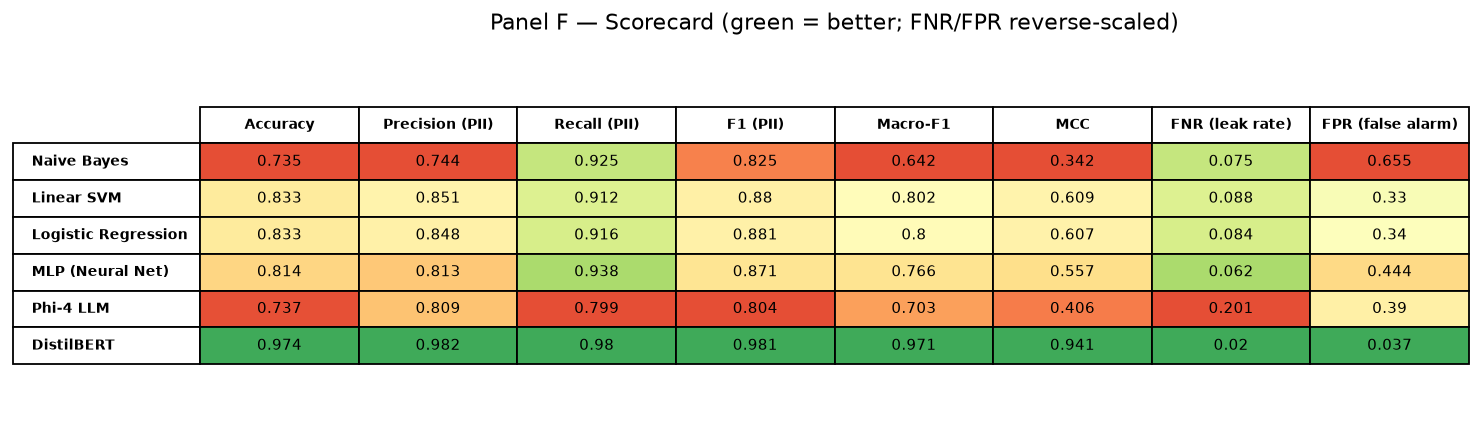

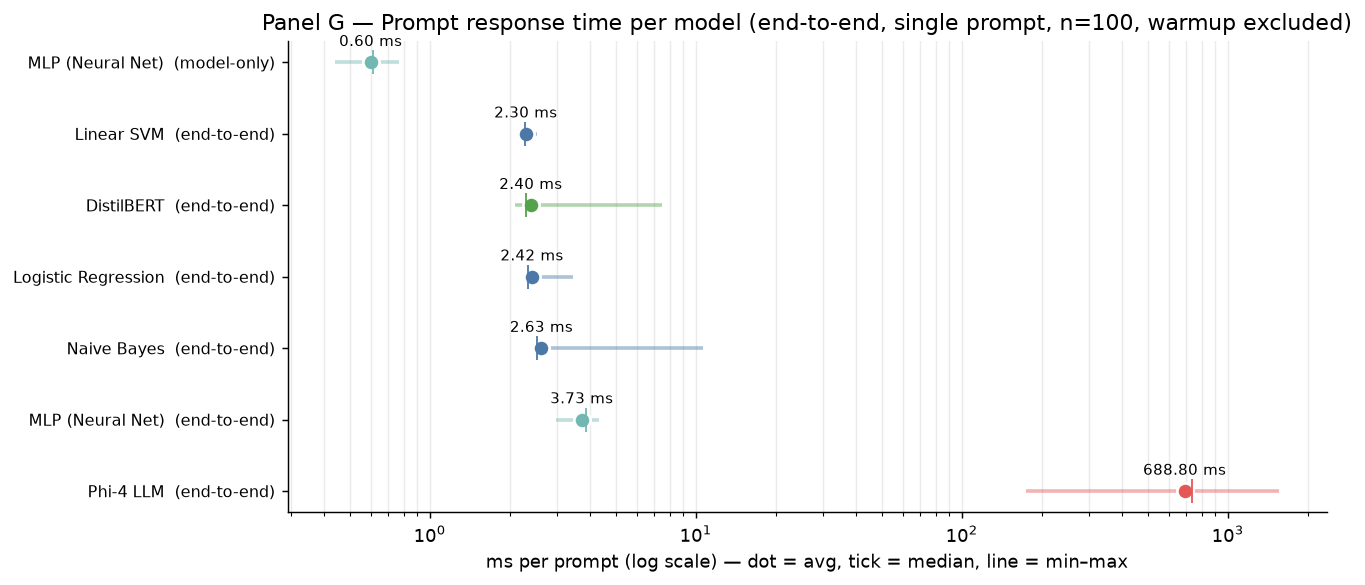

In [9]:
# embed the committed dashboard figures from 06 (scorecard + response time)
from IPython.display import Image, display as idisplay
for fig_name in ("panelF_scorecard.png", "panelG_latency.png"):
    fig_path = repo_root / "notebooks" / "figures" / fig_name
    if fig_path.exists():
        idisplay(Image(filename=str(fig_path)))
    else:
        print(f"{fig_name} not found — run 06_pii_evaluation_error.ipynb to regenerate it.")


The always-predict-PII baseline shows why recall cannot be used alone: it misses no PII, but it rejects every safe example. The tuned classical models provide a genuinely useful balance (PII F1 ≈ 0.88 at recall ≈ 0.91–0.92); the MLP at its deployed threshold is the best non-transformer leak-stopper (1,350 false negatives); and multilingual DistilBERT is the strongest model overall.

The Phi-4 comparison is no longer only directional: DistilBERT was re-evaluated on **Phi-4's exact 3,000-row stratified subset** (`results/distilbert_on_phi4_subset.csv`). On identical examples, DistilBERT reaches PII recall ≈ 0.98 / precision ≈ 0.98 versus Phi-4's 0.80 / 0.81 after its prompt fix — a controlled, same-example gap of roughly 18 recall points, closing the comparability caveat raised in the error-analysis doc.


## 12. Response Time per Prompt

A pre-submission screen must answer before the user notices it exists, so per-prompt latency is a headline
result next to F1. All models were timed under **one shared protocol** (`06` Panel G): end-to-end from raw
text to decision (featurization or tokenization + model), single prompt at a time, the same 100-prompt
test sample (seed 42), warmup excluded, `time.perf_counter`. The classical and MLP timings include the full
TF-IDF + text-feature + pattern-feature extraction per prompt; DistilBERT includes tokenization; Phi-4
includes the complete local Ollama round trip.


In [10]:
# Response-time table from the shared benchmark file (plus the MLP forward-only reference row).
lat = pd.read_csv(repo_root / "results" / "latency_benchmark.csv")
lat["model"] = lat["model"].replace({"Phi-4": "Phi-4 14B"})
lat = lat.rename(columns={"model": "Model", "n": "N prompts", "mean_ms": "Avg ms/prompt",
                          "median_ms": "Median ms/prompt", "min_ms": "Min ms/prompt", "max_ms": "Max ms/prompt"})
lat["Scope"] = "end-to-end"

fwd = pd.read_csv(repo_root / "results" / "mlp_latency_benchmark.csv")
fwd = fwd[fwd["stage"] == "MLP forward only"].rename(columns={
    "stage": "Model", "n": "N prompts", "avg_ms_per_prompt": "Avg ms/prompt",
    "median_ms_per_prompt": "Median ms/prompt", "min_ms_per_prompt": "Min ms/prompt",
    "max_ms_per_prompt": "Max ms/prompt"})
fwd["Model"] = "MLP (forward pass only)"
fwd["Scope"] = "model-only reference"

latency_table = (pd.concat([lat, fwd], ignore_index=True)
                   .sort_values("Avg ms/prompt")
                   .round({"Avg ms/prompt": 2, "Median ms/prompt": 2, "Min ms/prompt": 2, "Max ms/prompt": 2}))
display(latency_table[["Model", "Scope", "N prompts", "Avg ms/prompt", "Median ms/prompt", "Min ms/prompt", "Max ms/prompt"]])

_ph = latency_table.set_index("Model")["Avg ms/prompt"]
print(f"Phi-4 is ~{_ph.get('Phi-4 14B', float('nan'))/_ph.get('DistilBERT', float('nan')):,.0f}x slower per prompt than DistilBERT "
      f"and ~{_ph.get('Phi-4 14B', float('nan'))/_ph.get('Logistic Regression', float('nan')):,.0f}x slower than Logistic Regression.")


,Model,Scope,N prompts,Avg ms/prompt,Median ms/prompt,Min ms/prompt,Max ms/prompt
6,MLP (forward pass only),model-only reference,100,0.60,0.61,0.44,0.77
4,Linear SVM,end-to-end,100,2.30,2.29,2.22,2.53
0,DistilBERT,end-to-end,100,2.40,2.30,2.10,7.50
2,Logistic Regression,end-to-end,100,2.42,2.33,2.25,3.45
3,Naive Bayes,end-to-end,100,2.63,2.54,2.48,10.69
5,MLP (Neural Net),end-to-end,100,3.73,3.88,2.98,4.33
1,Phi-4 14B,end-to-end,100,688.80,736.00,174.30,1564.90


Phi-4 is ~287x slower per prompt than DistilBERT and ~285x slower than Logistic Regression.


Every screening-class model answers in **2–4 ms per prompt** — the classical models ~2.3–2.6 ms, DistilBERT
~2.4 ms, and the MLP ~3.9 ms — because featurization dominates these pipelines (the MLP's forward pass alone is
~0.6 ms). Two practical conclusions: **DistilBERT's accuracy costs essentially nothing in latency** (on a local GPU it sits inside the
classical cluster, within ~0.1 ms of the fastest linear model), and the **Phi-4 baseline is disqualified for inline screening on speed alone** — ~689 ms
per prompt on average with a 174–1,565 ms range, roughly 200–300× the screening models, before considering its
weaker detection quality. The full distribution view is Panel G in
[`06_pii_evaluation_error.ipynb`](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/06_pii_evaluation_error.ipynb).


## 13. Error Analysis

The errors show that the models are not simply learning the same rule at different accuracy levels.
The full data-driven analysis — FN/FP mining, language-leak tables, and placeholder statistics for every
model — is in [`06_pii_evaluation_error.ipynb`](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/06_pii_evaluation_error.ipynb) (Sections 4–6).

| Error pattern | Evidence | Interpretation |
|---|---|---|
| Placeholder artifacts | Phi-4 initially over-flagged bracketed placeholders (fixed by a targeted prompt change); DistilBERT under-flags around them; the MLP's missed PII contains them at ~2× the base rate | A dataset/preprocessing artifact that affects **every** model, in opposite directions |
| Dense numbers and structured IDs | DistilBERT and Phi-4 missed numeric strings embedded in narrative text; MLP misses include ID codes like `TE77374VW` | Shape alone is ambiguous without a nearby context cue |
| Business URLs and identifiers | Phi-4 flags generic organizational URLs; some DistilBERT false positives contain real-looking financial or vehicle identifiers labeled safe | The boundary between personal PII and business identifiers is not clean in the ground truth |
| Non-English context | Phi-4 false negatives skew non-English; the MLP's missed PII skews French/Dutch/German (its TF-IDF vocabulary fragments across languages) | Aggregate performance conceals weaker language-specific performance |
| Implicit, pattern-free PII | MLP misses are shorter (median 125 vs 146 chars), less HTML-marked (14.6% vs 26.2%), and dominated by prose disclosures (coordinates, city-tied job news) | Pattern features cannot catch what has no surface pattern — the gap contextual embeddings close |
| Recall versus usability | Naive Bayes reaches recall 0.925 only by flagging ~66% of safe prompts; the MLP's deployed 0.02 threshold accepts ~4,700 false alarms to cut leaks 55% | A deployment threshold balances privacy risk with alert fatigue |

The targeted Phi-4 placeholder fix demonstrates the value of error analysis: it reduced false positives by 165
and improved macro F1 by 0.05, while increasing false negatives by 80 — a prompt change shifts the operating
point rather than uniformly improving every metric. Representative examples in the supporting notebooks are
quoted with truncation; the dataset's PII is synthetic/masked by construction.

### 13.1 Representative misses (truncated; all PII in this dataset is synthetic by construction)

Four prompts every lightweight model (LR, SVM, MLP) let through — implicit or unusually-shaped identifiers
with no surface pattern:

> *"Contrato: Este acuerdo establece que G■■■■ debe proporcionar la dirección `3bAYGvHOhwLkOb…` como pago…"* — a wallet-style address in Spanish legal prose
> *"Krishnaraj, make sure to read the articles on `https://www.lewis-johnson.com/` for our next discussion…"* — a name + personal URL with no digits at all
> *"La manipulación de pruebas mediante el uso de `Z7993943C`…"* — a national-ID-shaped code inside narrative Spanish
> *"Transactions douteuses par I■■■ B■■■■, IBAN : `CH 1811 5439 …`"* — a spaced IBAN that defeats the long-number regex

DistilBERT's 447 misses are a *different* population — dense numerics with no context cue, exactly as
`docs/brandon_error_analysis.md` predicts:

> *"Operation audit dated dicembre 2º, 2069, involving primary access protocol through `5587290147`."*
> *"Engage `31213457238903216` for performance metrics by 16/10/2074."*
> *"…verifica tramite OTP come `7 6708` per tutte le transazioni…"*

### 13.2 Leak rate by language (test set, per 06 §6.1)

Missed-PII rate among true-PII prompts, by heuristic language guess — the measurement behind the
"non-English skew" claim:

| Language | LR | Naive Bayes | Linear SVM | MLP @0.02 | DistilBERT |
|---|---|---|---|---|---|
| French | 8.7% | 11.2% | 8.9% | 6.9% | **1.6%** |
| English | 8.7% | 2.7% | 8.9% | 6.7% | 2.8% |
| German | 8.1% | 6.4% | 8.6% | 5.3% | 2.5% |
| Spanish | 8.8% | 12.7% | 10.0% | 6.6% | 1.8% |
| Italian | 7.2% | 12.6% | 7.6% | 4.9% | **1.3%** |
| Dutch | 10.8% | 3.0% | 10.5% | 7.5% | 2.1% |

Two readings: the linear models leak fairly uniformly (~7–11%) because TF-IDF fragments every language's
vocabulary equally, while Naive Bayes is wildly uneven (2.7% English vs ~13% Spanish/Italian); and
DistilBERT's multilingual pre-training flattens the leak rate to ~1–3% *in every language* — it is the only model that stays
below 3% leakage in every language (Naive Bayes touches 2.7% on English only by flagging two-thirds of
all safe prompts). This directly supports the
multilingual-checkpoint decision (D001) and addresses the per-language stretch goal (D005).


## 14. Key Project Decisions

Several decisions materially changed the validity or interpretation of the project:

1. **Convert token labels into one document label.** This aligned the dataset with a pre-submission allow-or-flag decision.
2. **Clean before freezing the split.** Removing blank and duplicate text eliminated the identified duplicate-overlap leakage risk.
3. **Use one shared split.** Every trained model uses the same seed-42 train, validation, and test data.
4. **Prohibit answer-derived features.** Token labels, privacy masks, and original PII categories are not model inputs.
5. **Prioritize PII recall and F1.** Accuracy alone does not represent the cost of missed PII or excessive blocking.
6. **Fit feature transformations on training data only.** TF-IDF vocabulary and numeric scaling are not informed by validation or test text.
7. **Use multilingual DistilBERT with 256-token inputs.** This addressed the multilingual data while covering nearly all analyzed examples at lower cost than 512 tokens.
8. **Run Phi-4 locally on a stratified subset.** This preserved data locality and made the baseline feasible, while requiring a clear comparability limitation.
9. **Make a targeted prompt change after error analysis.** The placeholder fix addressed a specific failure pattern rather than tuning blindly against the final metric.

## 15. Discussion and Limitations

### Interpretation

The current evidence supports the main project direction. A model trained specifically for PII screening can substantially outperform an instruction-prompted general-purpose LLM baseline on this task. Multilingual DistilBERT produced the strongest results, suggesting that contextual representations matter for prompt-like text containing varied languages and formats.

The classical results are also practically meaningful. Logistic Regression and Linear SVM reached PII F1 near 0.88 in the current evaluation and can run with a sparse feature pipeline. Naive Bayes caught slightly more PII but generated many more false positives. This illustrates a realistic deployment choice: maximize detection, or preserve a more usable balance between warnings and missed cases.

Latency **was** measured under one controlled benchmark (Section 12): every screening-class model answers in 2–4 ms per prompt end-to-end, while the Phi-4 baseline needs ~689 ms with high variance. The speed argument for lightweight screening is therefore a demonstrated result — with the nuance that on a local GPU, DistilBERT is the most accurate model while costing essentially the same per prompt as the fastest classical pipelines (~2.4 vs ~2.3 ms), so the classical models' remaining advantages are hardware independence (CPU-only inference) and operational simplicity, not raw speed.

### Limitations

- **Narrow target definition:** the label represents dataset-annotated PII, not all sensitive or confidential information.
- **Dataset artifacts:** placeholders, HTML-like forms, and structured formatting may provide shortcuts that differ from real employee prompts.
- **Ground-truth ambiguity:** some safe examples contain real-looking financial, vehicle, or business identifiers, complicating error interpretation.
- **Unequal evaluation size (partially addressed):** Phi-4 uses a 3,000-row stratified subset; DistilBERT was re-evaluated on that exact subset for a controlled comparison, but the classical models and MLP still report full-test numbers only.
- **Aggregate multilingual results:** the project does not yet report performance separately by language, so weaker languages may be hidden by the overall score.
- **Incomplete feature ablation:** building multiple feature blocks does not by itself prove that each engineered block improved performance. A controlled same-model ablation is needed for that claim.
- **Compute and reproducibility:** transformer fine-tuning and local Phi-4 inference require more hardware and time than the classical pipeline.
- **No production evaluation:** the project does not test user behavior, alert fatigue, adversarial obfuscation, data drift, latency, or integration with an actual LLM gateway.

For deployment, the model would need threshold calibration on organization-specific data, broader sensitive-data categories, monitoring for drift, and a clear workflow for warnings, overrides, and human review.

## 16. Conclusion

The project asks whether purpose-built machine learning can detect privacy-sensitive prompt text before it reaches an external LLM, and how those models compare with a general-purpose LLM baseline. The results answer the first part positively: every trained model detects PII far better than the majority-class baseline while preserving meaningful safe-class performance.

The hypothesis is supported on both axes, and the strongest comparison is now controlled: on **Phi-4's exact 3,000-row subset**, multilingual DistilBERT reaches ≈ 0.98 PII recall and precision versus 0.80/0.81 for the post-fix Phi-4 baseline — and on the full 32,543-row test set DistilBERT holds ≈ 0.98 PII F1 with 447 false negatives. The specialized models are also faster by orders of magnitude: 2–4 ms per prompt end-to-end versus ~689 ms for Phi-4 under the same single-prompt benchmark.

For a screening system that prioritizes detection quality, **multilingual DistilBERT is the recommendation** — on local GPU hardware it is the most accurate model measured at effectively the same per-prompt cost as the fastest classical pipelines (~2.4 vs ~2.3 ms). Where CPU-only inference or operational simplicity matters more, **tuned Logistic Regression** (PII F1 0.881, recall 0.916, ~2.3 ms) is the credible lightweight alternative, and the **MLP's deployed 0.02 threshold** offers the lowest non-transformer leak rate (1,350 false negatives) when recall is the overriding concern. Phi-4 alone is not a competitive classifier for this narrow task: it is the least accurate and slowest option measured.

Next steps: evaluate the classical models and MLP on the shared 3,000-row subset to complete the same-example grid; report performance by language and PII category (the error analysis already shows non-English text drives the misses); run the controlled feature-set ablation (TF-IDF alone vs text vs pattern vs combined on one model); test adversarially obfuscated identifiers; and validate the detector on real organization-specific prompts with appropriate privacy controls.


## Supporting Notebooks

- [01 · Data EDA](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/01_data_eda.ipynb)
- [02 · Feature Engineering](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/02_feature_engineering.ipynb)
- [03 · Classical Models](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/03_classical_models.ipynb)
- [04 · Neural Network](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/04_neural_net.ipynb)
- [05 · DistilBERT](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/05_distilbert.ipynb)
- [06 · Evaluation & Error-Analysis Dashboard](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/06_pii_evaluation_error.ipynb)
- [Transformer/LLM analysis (Phi-4 & DistilBERT)](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/docs/brandon_error_analysis.md)
- [Decision log](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/docs/decisions.md) · [Project plan](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/docs/project_plan.md)


## Project Repository

[Cyber-207/cyber207_specialized_PII_detection_comparison](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison)